# MethaneSET · plume bank
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IPL-UV/taco-methaneset/blob/main/methaneset-codes/notebooks/04_bank.ipynb)

**The synthetic plume bank: 238,545 projected enhancement maps (279 plumes x 855 solar geometries) and the 1,647 source 3D LES cubes they were selected from.**

What you will do here:
1. Open the bank and understand what one row means (a plume, a wind speed, a snapshot and a
   solar geometry on a 20 m grid aligned with the wind).
2. Query maps by geometry: the bank is indexed by solar zenith (SZA), the sun azimuth relative to
   the wind (RAA) and the wind speed.
3. Read one enhancement map, scale it to any emission rate (linear scaling) and look at its
   quality flags (`qa:*`, `edge:*`).
4. Open the raw LES cubes (`methaneset-bank-les`) and rebuild the column map from the 49 levels.
5. Where this goes: the injection pipeline (the full radiometric step) is described in the paper
   and will get its own notebook; here you see exactly what it consumes.

Data: `methaneset-bank` (238,545 maps) and `methaneset-bank-les` (1,647 cubes), CC-BY-4.0.
See also: `01_s2`, `02_l89`, `03_emit`.

## 1. Setup

In [1]:
import os, urllib.request
if not os.path.exists("common.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/IPL-UV/taco-methaneset/main/methaneset-codes/notebooks/common.py",
        "common.py")
try:
    import tacoreader, rasterio
except ImportError:
    %pip install "tacoreader>=2.4,<3" rasterio matplotlib pandas pyarrow
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import rasterio
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)
import common as C
C.style()
import tacoreader; print("tacoreader", tacoreader.__version__)

tacoreader 2.4.21


## 2. The bank in one table
One row = one enhancement map: a physical plume (an emitter, a wind speed and a snapshot) seen
from one solar geometry. The grid is 20 m, aligned with the wind direction; the sun is encoded as
its zenith angle (`sun:sza`) and its azimuth **relative to the wind** (`sun:raa`).

In [2]:
bank = C.load("methaneset-bank")
df = bank.data.to_pandas()
print(df.shape[0], "maps |", df["methane:plume_uid"].nunique(), "physical plumes |",
      df["methane:wind_speed"].nunique(), "wind speeds")
print("SZA values:", sorted(df["sun:sza"].unique())[:6], "...")
print("RAA values:", df["sun:raa"].nunique(), "| emitters:", sorted(df["methane:emitter"].unique())[:6])

[common] methaneset-bank: local


238545 maps | 279 physical plumes | 11 wind speeds
SZA values: [np.float64(0.0), np.float64(10.304846468766033), np.float64(19.98310652189998), np.float64(28.610459665965216), np.float64(36.02737338510361), np.float64(42.27368900609374)] ...
RAA values: 692 | emitters: ['a1', 'a2', 'a3', 'a4', 'a5', 'a6']


## 3. Query by geometry
A user with an observation geometry (SZA, RAA and wind speed) asks for the
closest map. Here we pick a geometry and look up its nearest match.

In [3]:
q = df.query("`sun:sza` > 60 and `methane:wind_speed` == 3")
row = q.iloc[(q["sun:raa"] - 34).abs().argsort()[:1]].iloc[0]
print("chosen map:", row["id"], "| plume", row["methane:plume_uid"], "| emitter", row["methane:emitter"],
      "| wind", row["methane:wind_speed"], "m/s | SZA", round(float(row["sun:sza"]), 1), "| RAA", round(float(row["sun:raa"]), 1))

chosen map: a5_w03.0_s061_sza61.2_raa034.3 | plume a5_w03.0_s061 | emitter a5 | wind 3.0 m/s | SZA 61.2 | RAA 34.3


## 4. One map: the enhancement and its flags
The map is a float32 GeoTIFF in **ppb** at a reference emission rate of 3,000 kg/h, stored on a
canvas that extends towards the anti-solar side (the parallax shift) and zero-filled where there is
no plume mass.

map: (116, 111) float32 | peak 503 ppb | mean 21.23 ppb
quality flags: ime_before 2.73e+05, ime_after 2.73e+05, threshold_rel 1.0e-04


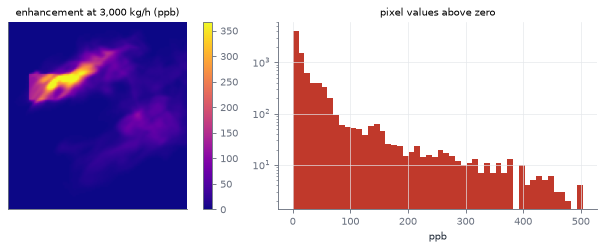

In [4]:
en = C.read(bank.read(int(row.name)), bands=1)
print("map:", en.shape, en.dtype, "| peak %.0f ppb | mean %.2f ppb" % (np.nanmax(en), np.nanmean(en)))
print("quality flags: ime_before %.3g, ime_after %.3g, threshold_rel %.1e" % (
    row["qa:ime_before"], row["qa:ime_after"], row["qa:threshold_rel"]))
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
im = ax[0].imshow(en, cmap=C.CMAP_ENH, vmax=np.nanpercentile(en, 99.5))
ax[0].set_title("enhancement at 3,000 kg/h (ppb)", fontsize=9); fig.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].hist(en[en > 0], bins=50, color=C.PALETTE["ch4"]); ax[1].set_yscale("log")
ax[1].set_title("pixel values above zero", fontsize=9); ax[1].set_xlabel("ppb")
for a in [ax[0]]: a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()

## 5. Scale to any emission rate
The stored map is linear: to target an emission rate $Q$ just multiply by $Q / Q_{\mathrm{ref}}$
with $Q_{\mathrm{ref}} = 3{,}000$ kg h$^{-1}$ (the tracer is passive and the non-linear absorption
is applied later, during injection).

Q = 10000 kg/h -> peak 1678 ppb | mask covers 27.0% of the canvas
canvas edges (ppb): upwind 0.0 downwind 53.9 top 0.8 bottom 3.8


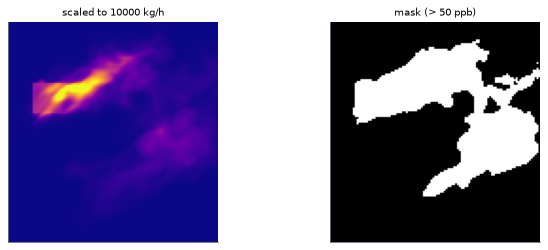

In [5]:
Q = 10_000
en_q = en * (Q / 3000.0)
m = en_q > 50                                    # a conservative plume mask
print(f"Q = {Q} kg/h -> peak {np.nanmax(en_q):.0f} ppb | mask covers {100*m.mean():.1f}% of the canvas")
print("canvas edges (ppb): upwind %.1f downwind %.1f top %.1f bottom %.1f" % (
    row["edge:upwind_ppb"], row["edge:downwind_ppb"], row["edge:top_ppb"], row["edge:bottom_ppb"]))
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].imshow(en_q, cmap=C.CMAP_ENH, vmax=np.nanpercentile(en_q, 99.5)); ax[0].set_title(f"scaled to {Q} kg/h", fontsize=9)
ax[1].imshow(m, cmap="gray"); ax[1].set_title("mask (> 50 ppb)", fontsize=9)
for a in ax: a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()

Filters worth knowing: `edge:downwind_width_m` measures the visible plume width at the exit edge,
and `qa:ime_before`/`qa:ime_after` quantify the mass zeroed by the compression threshold. The build
already enforces the edge rule (`ENTRADA_FRAC`/`LATERAL_FRAC = 2 %`), so no distributed map exceeds
2 % of its peak on the upwind or lateral borders.

## 6. The raw LES cubes (`methaneset-bank-les`)
Each row is a 3D tracer cube with 49 vertical levels; the per-level heights are in
`grid:level_heights_m`. Summing the levels gives the column map; the section 7 projection is the idea behind
how the projected bank maps were produced (the full recipe adds the two paths of section 7).

In [6]:
les = C.load("methaneset-bank-les")
print(les.data.shape[0], "cubes |", [c for c in les.data.columns if c.startswith(("grid:", "simulation:"))][:6])
dfl = les.data.to_pandas()
r = dfl.iloc[0]
cube = C.read(les.read(0))          # (49, nrows, ncols) in ppb
print("cube:", cube.shape, "| sum = column map, peak %.0f ppb" % np.nanmax(cube.sum(axis=0)))

[common] methaneset-bank-les: local


1647 cubes | ['grid:level_heights_m']


cube: (49, 90, 120) | sum = column map, peak 2993 ppb


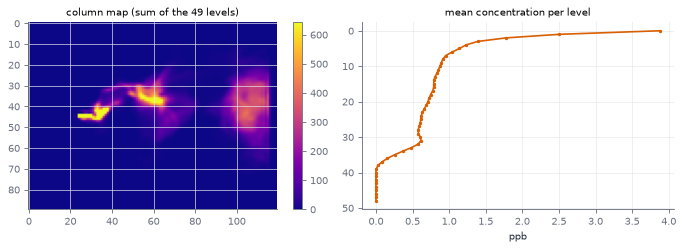

In [7]:
col = cube.sum(axis=0)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
im = ax[0].imshow(col, cmap=C.CMAP_ENH, vmax=np.nanpercentile(col, 99.5))
ax[0].set_title("column map (sum of the 49 levels)", fontsize=9); fig.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].plot(cube.mean(axis=(1, 2)), range(cube.shape[0]), marker="o", ms=2, color=C.PALETTE["l89"])
ax[1].invert_yaxis(); ax[1].set_title("mean concentration per level", fontsize=9); ax[1].set_xlabel("ppb")
fig.tight_layout(); plt.show()

## 7. From the LES cube to the projected map

For an off-nadir sun the column map is not a plain vertical sum. The pipeline (`pipeline/bank/core/projection.py`)
applies two paths and combines them:

- the **solar path**: every level is shifted on the ground by `k*DZ*tan(SZA)` away from the sun
  (RAA + 180°, counterclockwise from the wind), with bilinear splitting so mass is conserved;
- the **nadir path**: the unshifted column, weighted by the air-mass factor `a_v = 1`, against
  `a_s = 1/cos(SZA)` for the solar path.

The relaxation border is trimmed first. Let us reproduce that recipe for one cube.

In [8]:
# a stored map for emitter p6, 3 m/s, SZA ~61 (a geometry that also has a raw cube)
q = df.query("`methane:emitter` == 'p6' and `methane:wind_speed` == 3")
brow = q.iloc[(q["sun:sza"] - 61.2).abs().argsort()[:1]].iloc[0]
stored = C.read(bank.read(int(brow.name)), bands=1)
print("stored map: %s | SZA %.1f RAA %.1f | snapshot %s" % (
    stored.shape, float(brow["sun:sza"]), float(brow["sun:raa"]), brow["methane:snapshot_index"]))

stored map: (74, 116) | SZA 61.2 RAA 354.3 | snapshot 98


In [9]:
# its LES cube: same emitter, wind and snapshot
ql = dfl.query("`methane:emitter` == 'p6' and `methane:wind_speed` == 3")
lrow = ql.iloc[(ql["methane:snapshot_index"] - float(brow["methane:snapshot_index"])).abs().argsort()[:1]].iloc[0]
cube = C.read(les.read(int(lrow.name)), nan_nodata=False)     # (49, nrows, ncols) ppb
z = np.asarray(lrow["grid:level_heights_m"], dtype="float32")
print("cube: %s | snapshot %s | 49 levels | real heights %.1f to %.1f m" % (cube.shape, lrow["methane:snapshot_index"], z.min(), z.max()))

cube: (49, 90, 120) | snapshot 98 | 49 levels | real heights 9.9 to 991.8 m


In [10]:
RELAX = 5                                       # relaxation border the pipeline trims
vol = cube[:, RELAX:-RELAX, RELAX:-RELAX]        # (49, 80, 110)
px = 20.0                                       # LES pixel (m)
sza, raa = float(brow["sun:sza"]), float(brow["sun:raa"])

def project(heights):
    ang = np.radians(raa + 180.0)               # away from the sun
    s = heights * np.tan(np.radians(sza)) / px  # pixel shift of each level
    dx, dy = s * np.cos(ang), s * np.sin(ang)
    x_lo = min(0, int(np.floor(dx.min()))); x_hi = max(0, int(np.floor(dx.max())) + 1)
    y_lo = min(0, int(np.floor(dy.min()))); y_hi = max(0, int(np.floor(dy.max())) + 1)
    ny, nx = vol.shape[1:]
    sol = np.zeros((ny + y_hi - y_lo, nx + x_hi - x_lo)); nad = np.zeros_like(sol)
    for k in range(vol.shape[0]):
        ix, iy = int(np.floor(dx[k])), int(np.floor(dy[k])); fx, fy = dx[k] - ix, dy[k] - iy
        r, c, L = iy - y_lo, ix - x_lo, vol[k]
        sol[r:r+ny, c:c+nx]             += (1 - fx) * (1 - fy) * L
        sol[r:r+ny, c+1:c+1+nx]         += fx * (1 - fy) * L
        sol[r+1:r+1+ny, c:c+nx]         += (1 - fx) * fy * L
        sol[r+1:r+1+ny, c+1:c+1+nx]     += fx * fy * L
        nad[-y_lo:-y_lo+ny, -x_lo:-x_lo+nx] += L
    a_s = 1.0 / np.cos(np.radians(sza))
    return (a_s * sol + nad) / (a_s + 1.0), sol, x_lo, y_lo

nominal = np.arange(vol.shape[0]) * px           # pipeline: level k sits at k*20 m
comb_nom, sol, xn, yn = project(nominal)
comb_real, _, xr, yr = project(z)                # z = real level heights
share = 1.0 / (1.0 / np.cos(np.radians(sza)) + 1.0)
print("nadir share at SZA %.1f: %.0f%% of the map is the unshifted column" % (sza, 100 * share))
x0, y0 = max(xn, xr), max(yn, yr)                # align both canvases on the same ground origin
x1 = min(xn + comb_nom.shape[1], xr + comb_real.shape[1])
y1 = min(yn + comb_nom.shape[0], yr + comb_real.shape[0])
diff = np.abs(comb_real[y0-yr:y1-yr, x0-xr:x1-xr] - comb_nom[y0-yn:y1-yn, x0-xn:x1-xn])
print("nominal vs real heights: p95 |difference| = %.1f ppb" % np.percentile(diff, 95))

nadir share at SZA 61.2: 33% of the map is the unshifted column
nominal vs real heights: p95 |difference| = 7.4 ppb


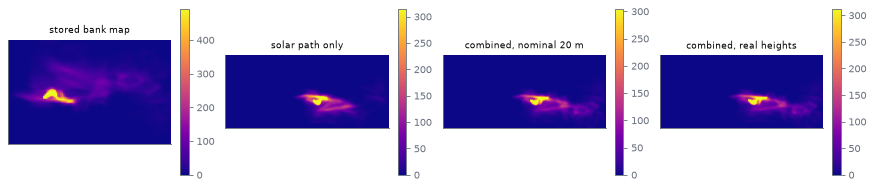

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(11, 3.0))
panels = [("stored bank map", stored), ("solar path only", np.flipud(sol)),
          ("combined, nominal 20 m", np.flipud(comb_nom)), ("combined, real heights", np.flipud(comb_real))]
for a, (t, m) in zip(ax, panels):
    im = a.imshow(m, cmap=C.CMAP_ENH, vmax=np.nanpercentile(m, 99.5))
    a.set_title(t, fontsize=8); a.set_xticks([]); a.set_yticks([]); fig.colorbar(im, ax=a, fraction=0.046)
fig.tight_layout(); plt.show()

The nadir share is the part of the map that is *not* shifted (about a third at SZA 61°), which is
why a plain shifted sum does not reproduce the bank. The recipe above matches the pipeline; getting
a *pixel-exact* copy of one distributed map additionally needs its crop and threshold step
(`05_generate_tifs.py`). On the height grid, using the real `grid:level_heights_m` instead of the
nominal 20 m grid moves individual pixels by under ~10 ppb at the 95th percentile here, so both are usable (the pipeline
ships the nominal one).

## 8. Wrap-up
- `methaneset-bank` gives ready-to-use 2D enhancements indexed by (SZA, RAA, wind speed); every
  map scales linearly to any emission rate.
- `methaneset-bank-les` gives the raw 3D cubes, so any solar geometry outside the sampled grid can
  be regenerated (shift each level, then sum).
- The injection step (converting the enhancement into a radiometric perturbation with the
  transmittance LUT) is the topic of the injection notebook and of the paper's Methods.

Next: `01_s2`, `02_l89`, `03_emit`. Website: https://ipl-uv.github.io/taco-methaneset

```bibtex
@article{contreras2026methaneset,
  title   = {MethaneSET: Unified Multi-Sensor AI-Ready Datasets for
             Satellite-Based Methane Plume Detection},
  author  = {Contreras, Julio and Giner, Carlos and Aybar, Cesar
             and Mateo-Garcia, Gonzalo and Gorrono, Javier
             and Montero, David and Mahecha, Miguel D.
             and Guanter, Luis and Gomez-Chova, Luis},
  journal = {Scientific Data},
  year    = {2026}
}
```